In [5]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils.DataLoader import load_propeller_dict
import scienceplots
plt.style.use(['science', 'no-latex'])

In [6]:
prop_name, blade_dict = load_propeller_dict('../Data/10x7E')[0]

environment = Environment(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    p_ref=2e-5,
)
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    environment=environment,
    simulation=simulation,
    use_cuda_timing=False,
)

bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=[3000, 7000],
    J=[0.0, 0.5],
)
performance = bemt.performance

print(f'Propeller: {prop_name}')
performance

Propeller: 10x7E


thrust    torque  thrust_coefficient  torque_coefficient  \
rpm    v_inf                                                                   
3000.0 0.000000   1.260426  0.025619            0.098879            0.007912   
       6.350000   0.521640  0.018073            0.040922            0.005582   
7000.0 0.000000   8.059078  0.134538            0.116124            0.007632   
       14.816667  4.559620  0.130899            0.065700            0.007426   

                  figure_of_merit  
rpm    v_inf                       
3000.0 0.000000          0.499010  
       6.350000          0.188325  
7000.0 0.000000          0.658408  
       14.816667         0.287984

In [7]:
sol = bemt.solution_for(rpm=7000, v_inf=0.0)
sol.head()

,r,dr,chord,twist,phi,alpha,Cl,Cd,u,a_prime,d_t,d_q,F,W,Re,Ma,ds,dp
section,,,,,,,,,,,,,,,,,,
0,0.027940,0.001524,0.022291,45.3524,13.713516,31.638884,0.846652,0.967638,3.907770,0.218064,0.009575,0.000306,0.956496,16.484775,24869.718926,0.048061,0.014283,0.000043
1,0.029464,0.001524,0.022967,43.8433,13.486608,30.356692,0.843054,0.913623,4.110796,0.206262,0.011234,0.000359,0.961620,17.629319,27402.569028,0.051397,0.014296,0.000046
2,0.030988,0.001524,0.023520,42.4018,13.234119,29.167681,0.838185,0.862148,4.300900,0.194752,0.012995,0.000414,0.966180,18.790366,29911.449542,0.054782,0.014451,0.000042
3,0.032512,0.001524,0.023983,41.0356,12.968461,28.067139,0.832229,0.814319,4.478297,0.183863,0.014844,0.000472,0.970236,19.959502,32397.010126,0.058191,0.014207,0.000045
4,0.034036,0.001524,0.024402,39.7404,12.703690,27.036710,0.825614,0.769074,4.649227,0.173583,0.016803,0.000533,0.973766,21.136521,34907.000070,0.061623,0.013949,0.000047


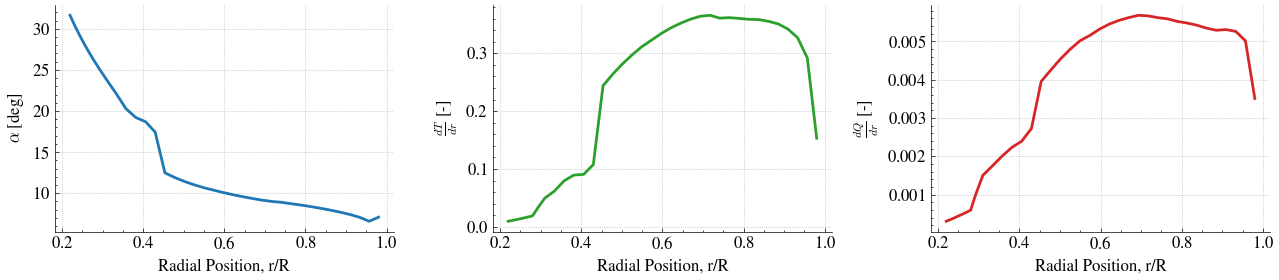

In [8]:
r = sol['r'].to_numpy()
norm_r = r / blade_dict['tip_radius']

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(norm_r, sol['alpha'].to_numpy(), linewidth=2, color='tab:blue')
axes[0].set_xlabel('Radial Position, r/R', fontsize=12)
axes[0].set_ylabel('$\\alpha$ [deg]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both', labelsize=12)

axes[1].plot(norm_r, sol['d_t'].to_numpy(), linewidth=2, color='tab:green')
axes[1].set_xlabel('Radial Position, r/R', fontsize=12)
axes[1].set_ylabel('$\\frac{dT}{dr}$ [-]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both', labelsize=12)

axes[2].plot(norm_r, sol['d_q'].to_numpy(), linewidth=2, color='tab:red')
axes[2].set_xlabel('Radial Position, r/R', fontsize=12)
axes[2].set_ylabel('$\\frac{dQ}{dr}$ [-]', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both', labelsize=12)

plt.tight_layout()
plt.show()